In [66]:
# 2차 EDA를 위해 Netflix 콘텐츠 단위 데이터와 TMDB 메타데이터를 불러오기

import pandas as pd
import matplotlib.pyplot as plt
# 로그 변환에 사용할 NumPy 불러오기
import numpy as np

In [67]:
# 2차 EDA에 사용할 Netflix 분석 데이터와 TMDB 메타데이터 불러오기

import pandas as pd

netflix_tv_df = pd.read_csv(
    "../DATA/PROCESSED/netflix_tv_analysis.csv"
)

tmdb_df = pd.read_csv(
    "../DATA/PROCESSED/tmdb_metadata.csv"
)

print("Netflix:", netflix_tv_df.shape)
print("TMDB:", tmdb_df.shape)

Netflix: (159, 13)
TMDB: (402, 15)


In [68]:
# Netflix TV 분석 데이터와 TMDB 메타데이터를 작품명 기준으로 병합

merged_df = netflix_tv_df.merge(
    tmdb_df,
    left_on="show_title",
    right_on="netflix_title",
    how="left"
)

print(merged_df.shape)

(159, 28)


In [69]:
# 병합 후 TMDB 정보가 빠진 작품 수를 확인

print("TMDB 미매칭:", merged_df["tmdb_id"].isna().sum())

TMDB 미매칭: 0


In [70]:
# 같은 show_title이 여러 시즌으로 중복되어 있는지 확인

print("show_title 중복:", merged_df["show_title"].duplicated().sum())

show_title 중복: 28


In [71]:
# 같은 show_title이 여러 행에 나타나는 중복 작품들을 확인

duplicate_titles = merged_df[
    merged_df["show_title"].duplicated(keep=False)
].sort_values("show_title")

print(
    duplicate_titles[
        [
            "content_key",
            "show_title",
            "category",
            "max_cumulative",
            "long_hit",
            "first_rank",
            "first_week_hours"
        ]
    ].to_string(index=False)
)

                content_key        show_title         category  max_cumulative  long_hit  first_rank  first_week_hours
        CoComelon: Season 1         CoComelon     TV (English)               1         0          10           9140000
        CoComelon: Season 3         CoComelon     TV (English)               5         1           9          11430000
        CoComelon: Season 4         CoComelon     TV (English)               5         1           8          15930000
        Cobra Kai: Season 1         Cobra Kai     TV (English)               2         0           8          13450000
        Cobra Kai: Season 2         Cobra Kai     TV (English)               1         0          10          19340000
        Control Z: Season 1         Control Z TV (Non-English)               1         0           7           8580000
        Control Z: Season 2         Control Z TV (Non-English)               3         0           2          25430000
            Elite: Season 1             Elite TV

한 행 = Netflix 시즌/콘텐츠

Netflix 성과
long_hit
first_rank
first_week_hours
initial_country_reach
max_cumulative

+

TMDB 작품 특성
genres
original_language
production_countries
number_of_seasons
number_of_episodes
vote_average
...

In [72]:
# Netflix 시즌 데이터 중 TMDB 메타데이터가 연결되지 않은 행이 있는지 확인

print("TMDB 미매칭:", merged_df["tmdb_id"].isna().sum())

TMDB 미매칭: 0


In [73]:
# TMDB 정보가 매칭되지 않은 Netflix 작품을 확인

merged_df.loc[
    merged_df["tmdb_id"].isna(),
    ["content_key", "show_title", "category"]
]

,content_key,show_title,category


In [74]:
# 같은 show_title이 여러 시즌으로 존재하는 작품 수를 확인

duplicate_show_count = (
    merged_df.loc[
        merged_df["show_title"].duplicated(keep=False),
        "show_title"
    ]
    .nunique()
)

print("여러 시즌이 있는 작품 수:", duplicate_show_count)

여러 시즌이 있는 작품 수: 17


In [75]:
# Netflix + TMDB 병합 데이터의 컬럼별 결측치 개수를 확인

merged_df.isna().sum()

content_key                0
show_title                 0
category                   0
first_week                 0
last_week                  0
first_cumulative           0
max_cumulative             0
right_censored             0
long_hit                   0
first_rank                 0
first_week_hours           0
log_first_week_hours       0
initial_country_reach      1
netflix_title              0
tmdb_id                    0
tmdb_type                  0
genres                     0
original_language          0
production_countries       6
release_date             158
first_air_date             1
runtime                  158
episode_run_time           1
number_of_seasons          1
number_of_episodes         1
vote_average               0
vote_count                 0
popularity                 0
dtype: int64

In [76]:
# 병합된 최종 데이터의 크기와 컬럼을 확인

print("데이터 크기:", merged_df.shape)
print("\n컬럼:")
print(merged_df.columns.tolist())

데이터 크기: (159, 28)

컬럼:
['content_key', 'show_title', 'category', 'first_week', 'last_week', 'first_cumulative', 'max_cumulative', 'right_censored', 'long_hit', 'first_rank', 'first_week_hours', 'log_first_week_hours', 'initial_country_reach', 'netflix_title', 'tmdb_id', 'tmdb_type', 'genres', 'original_language', 'production_countries', 'release_date', 'first_air_date', 'runtime', 'episode_run_time', 'number_of_seasons', 'number_of_episodes', 'vote_average', 'vote_count', 'popularity']


1. release_date 158, runtime 158은 정상

사용하는 Netflix 데이터 159개는 기본적으로 TV 콘텐츠이나, 앞에서 예외로 하나 존재.

Dave Chappelle: The Closer
Netflix → TV (English)
TMDB → movie

그래서 최종적으로는:

TV    158개
movie   1개

형태일 가능성이 높음.

따라서:

release_date 결측 158개
runtime 결측 158개

영화 1개에만 값이 있어서 생긴 정상적인 구조적 결측.

반대로:

first_air_date 결측 1
number_of_seasons 결측 1
number_of_episodes 결측 1

도 바로 그 movie 1개 때문일 가능성이 높다.

In [77]:
# 병합 데이터에서 TMDB 기준 movie와 tv 작품 수를 확인

merged_df["tmdb_type"].value_counts()

tmdb_type
tv       158
movie      1
Name: count, dtype: int64

In [78]:
# 초기 국가 도달 수가 누락된 Netflix 콘텐츠를 확인

merged_df.loc[
    merged_df["initial_country_reach"].isna(),
    ["content_key", "show_title", "category", "first_week"]
]

,content_key,show_title,category,first_week
97,Octonauts: Above & Beyond: Season 1,Octonauts: Above & Beyond,TV (English),2021-09-12


In [79]:
# 초기 국가 도달 수 누락 원인을 확인하기 위해 Netflix 국가별 원본 데이터를 불러오기

country_df = pd.read_csv(
    "../DATA/RAW/[엔터] Netflix Top 10 Weekly Dataset/all-weeks-countries.csv",
    encoding="latin1"
)

In [80]:
# 초기 국가 도달 수가 누락된 작품이 국가별 Netflix 데이터에 존재하는지 확인

octonauts_country = country_df[
    country_df["show_title"] == "Octonauts: Above & Beyond"
]

print(octonauts_country.shape)
print(octonauts_country.head(20).to_string(index=False))

(0, 8)
Empty DataFrame
Columns: [country_name, country_iso2, week, category, weekly_rank, show_title, season_title, cumulative_weeks_in_top_10]
Index: []


In [81]:
# 국가별 Netflix 데이터에 Octonauts 관련 작품이 다른 제목으로 저장되어 있는지 확인

octonauts_candidates = country_df[
    country_df["show_title"].str.contains(
        "Octonauts",
        case=False,
        na=False
    )
]

print(octonauts_candidates.shape)

print(
    octonauts_candidates[
        ["show_title", "season_title", "category"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

(0, 8)
Empty DataFrame
Columns: [show_title, season_title, category]
Index: []


Octonauts: Above & Beyond는 국가별 Netflix 데이터에 아예 존재하지 않아서 initial_country_reach를 계산할 수 없는 것.

그래서 이 값은:

0이 아님
→ 데이터 없음
→ NaN 유지

로 처리

In [82]:
# TMDB 제작국가 정보가 없는 작품 6개를 확인

missing_production_country = merged_df.loc[
    merged_df["production_countries"].isna(),
    ["show_title", "tmdb_id", "tmdb_type", "genres", "original_language"]
]

print(missing_production_country.to_string(index=False))

                                     show_title  tmdb_id tmdb_type                genres original_language
            Cocaine Cowboys: The Kings of Miami   129206        tv           Documentary                en
                                      Dive Club   131830        tv                 Drama                en
                                          Elves    70059        tv       Animation, Kids                en
                                  Gone for Good   128068        tv Crime, Drama, Mystery                fr
Monsters Inside: The 24 Faces of Billy Milligan   132105        tv    Documentary, Crime                en
          Top Secret UFO Projects: Declassified   129677        tv           Documentary                en


In [83]:
# TV 작품의 episode_run_time에서 빈 리스트("[]")로 저장된 작품 수를 확인

empty_runtime_count = (
    merged_df["episode_run_time"]
    .astype(str)
    .eq("[]")
    .sum()
)

print("episode_run_time 빈 리스트:", empty_runtime_count)

episode_run_time 빈 리스트: 77


### episode_run_time 데이터 품질 확인

TMDB의 TV 상세정보에서 `episode_run_time`이 빈 리스트(`[]`)로 제공되는 사례가 다수 확인되었다.

- 분석 대상 TV 콘텐츠: 158개
- 빈 리스트: 77개
- 약 49%의 러닝타임 정보가 부족함

따라서 `episode_run_time`은 핵심 EDA 변수에서 우선 제외하고,
필요 시 보조 분석 변수로만 활용한다.

In [84]:
# 장르 문자열을 개별 장르 리스트로 분리한 뒤 한 장르씩 행으로 펼치기

genre_df = merged_df.copy()

genre_df["genre"] = genre_df["genres"].str.split(", ")

genre_df = genre_df.explode("genre")

print(genre_df[["show_title", "genres", "genre", "long_hit"]].head(10).to_string(index=False))

               show_title                                              genres              genre  long_hit
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family               Kids         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family Action & Adventure         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family          Animation         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family             Comedy         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family             Family         0
AlRawabi School for Girls                                               Drama              Drama         0
      Alice in Borderland                  Mystery, Drama, Action & Adventure            Mystery         1
      Alice in Borderland                  Mystery, Drama, Action & Adventure              Drama         1
      Alice in Borderland            

In [85]:
# 장르별 콘텐츠 수와 장기흥행 비율을 계산

genre_long_hit = (
    genre_df.groupby("genre")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

genre_long_hit

,content_count,long_hit_count,long_hit_rate
genre,,,
Soap,3,3,1.000000
Mystery,31,14,0.451613
Crime,42,17,0.404762
Drama,89,34,0.382022
Action & Adventure,30,6,0.200000
Sci-Fi & Fantasy,38,7,0.184211
Comedy,44,8,0.181818
Family,13,2,0.153846
Animation,27,4,0.148148


In [86]:
# 콘텐츠 수가 10개 이상인 장르만 남겨 장기흥행 비율을 비교

genre_long_hit_filtered = genre_long_hit[
    genre_long_hit["content_count"] >= 10
].sort_values("long_hit_rate", ascending=False)

genre_long_hit_filtered

,content_count,long_hit_count,long_hit_rate
genre,,,
Mystery,31,14,0.451613
Crime,42,17,0.404762
Drama,89,34,0.382022
Action & Adventure,30,6,0.200000
Sci-Fi & Fantasy,38,7,0.184211
Comedy,44,8,0.181818
Family,13,2,0.153846
Animation,27,4,0.148148
Kids,14,2,0.142857


In [87]:
# 장기흥행 비율을 퍼센트로 변환해 보기 쉽게 정리

genre_long_hit_filtered = genre_long_hit_filtered.copy()

genre_long_hit_filtered["long_hit_rate_pct"] = (
    genre_long_hit_filtered["long_hit_rate"] * 100
).round(1)

genre_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
genre,,,,
Mystery,31,14,0.451613,45.2
Crime,42,17,0.404762,40.5
Drama,89,34,0.382022,38.2
Action & Adventure,30,6,0.200000,20.0
Sci-Fi & Fantasy,38,7,0.184211,18.4
Comedy,44,8,0.181818,18.2
Family,13,2,0.153846,15.4
Animation,27,4,0.148148,14.8
Kids,14,2,0.142857,14.3


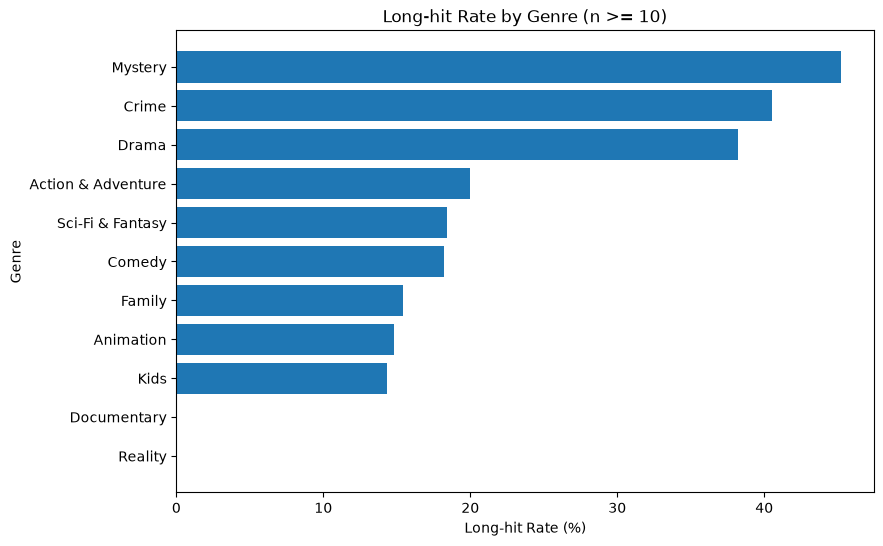

In [88]:
# 표본 10개 이상 장르의 장기흥행 비율을 막대그래프로 시각화

plot_data = genre_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Genre")
plt.title("Long-hit Rate by Genre (n >= 10)")

plt.show()

### 장르별 장기흥행 비율

표본 수가 10개 이상인 장르를 기준으로,
Mystery(45.2%), Crime(40.5%), Drama(38.2%) 순으로
상대적으로 높은 장기흥행 비율이 나타났다.

반면 Animation(14.8%), Kids(14.3%)는 상대적으로 낮았다.

다만 한 작품이 여러 장르에 동시에 포함될 수 있으므로,
이 결과는 각 장르의 독립적인 효과라기보다
해당 장르 특성을 포함한 콘텐츠의 장기흥행 경향으로 해석한다.

In [89]:
# Animation 장르가 포함된 작품만 추출해 장기흥행 여부와 장르 조합을 확인

animation_df = merged_df[
    merged_df["genres"].str.contains("Animation", na=False)
].copy()

print(animation_df.shape)

print(
    animation_df[
        [
            "show_title",
            "genres",
            "long_hit",
            "max_cumulative",
            "first_rank",
            "first_week_hours"
        ]
    ]
    .sort_values(
        ["long_hit", "max_cumulative"],
        ascending=[False, False]
    )
    .to_string(index=False)
)

(27, 28)
                    show_title                                                          genres  long_hit  max_cumulative  first_rank  first_week_hours
                        Arcane                 Animation, Action & Adventure, Sci-Fi & Fantasy         1               6           2          34170000
                     CoComelon                                                 Animation, Kids         1               5           9          11430000
                     CoComelon                                                 Animation, Kids         1               5           8          15930000
         The Seven Deadly Sins                 Animation, Action & Adventure, Sci-Fi & Fantasy         1               4           2          33240000
                     Big Mouth                                               Comedy, Animation         0               3           9          19570000
                  Cowboy Bebop        Animation, Action & Adventure, Sci-Fi & Fantasy

장르만으로는 설명 부족
↓
평점?
투표 수?
시즌/에피소드 수?
언어?
제작 국가?
초기 Netflix 성과?

애니메이션 콘텐츠 전체의 장기흥행 비율은 낮았지만, 장기흥행 사례 중에서는 Action & Adventure와 Sci-Fi & Fantasy가 결합된 작품이 일부 확인되었다.

In [90]:
# Animation 콘텐츠의 장기흥행 여부별 개수와 비율을 확인

animation_long_hit = animation_df["long_hit"].value_counts().sort_index()

print(animation_long_hit)

print(
    "\n장기흥행 비율:",
    round(animation_df["long_hit"].mean() * 100, 1),
    "%"
)

long_hit
0    23
1     4
Name: count, dtype: int64

장기흥행 비율: 14.8 %


In [91]:
# Animation 작품에서 Animation을 제외한 보조 장르별 등장 횟수와 장기흥행 횟수를 확인

animation_genre_df = animation_df.copy()

animation_genre_df["sub_genre"] = animation_genre_df["genres"].str.split(", ")
animation_genre_df = animation_genre_df.explode("sub_genre")

animation_genre_df = animation_genre_df[
    animation_genre_df["sub_genre"] != "Animation"
]

animation_subgenre = (
    animation_genre_df.groupby("sub_genre")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

animation_subgenre

,content_count,long_hit_count,long_hit_rate
sub_genre,,,
Kids,12,2,0.166667
Sci-Fi & Fantasy,15,2,0.133333
Action & Adventure,17,2,0.117647
Comedy,11,0,0.000000
Family,7,0,0.000000
Western,1,0,0.000000


### Animation 세부 장르 확인

Animation이 포함된 콘텐츠는 총 27개였으며,
이 중 장기흥행 콘텐츠는 4개로 장기흥행 비율은 14.8%였다.

Animation 콘텐츠의 보조 장르를 확인한 결과
Kids, Sci-Fi & Fantasy, Action & Adventure 등에서 일부 장기흥행 사례가 나타났다.

다만 Animation 전체 표본과 장기흥행 사례 수가 적기 때문에,
세부 장르별 차이를 일반화하기보다는 탐색적 결과로 해석한다.

또한 동일한 장르 조합에서도 장기흥행 여부가 달라지는 사례가 확인되어,
장르만으로 장기흥행을 설명하기는 어렵다고 판단했다.

In [92]:
# 원어별 콘텐츠 수와 장기흥행 비율을 계산

language_long_hit = (
    merged_df.groupby("original_language")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

language_long_hit

,content_count,long_hit_count,long_hit_rate
original_language,,,
da,1,1,1.000000
ko,8,5,0.625000
es,25,9,0.360000
en,89,25,0.280899
ja,11,2,0.181818
pt,6,1,0.166667
fr,6,1,0.166667
de,3,0,0.000000
is,1,0,0.000000


In [93]:
# 원어별 콘텐츠 수를 확인

merged_df["original_language"].value_counts()

original_language
en    89
es    25
ja    11
ko     8
pt     6
fr     6
de     3
hi     2
pl     2
ar     1
is     1
tr     1
da     1
it     1
no     1
sv     1
Name: count, dtype: int64

In [94]:
# 콘텐츠가 5개 이상인 언어만 남겨 장기흥행 비율을 비교

language_long_hit_filtered = language_long_hit[
    language_long_hit["content_count"] >= 5
].copy()

language_long_hit_filtered["long_hit_rate_pct"] = (
    language_long_hit_filtered["long_hit_rate"] * 100
).round(1)

language_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
original_language,,,,
ko,8,5,0.625000,62.5
es,25,9,0.360000,36.0
en,89,25,0.280899,28.1
ja,11,2,0.181818,18.2
pt,6,1,0.166667,16.7
fr,6,1,0.166667,16.7


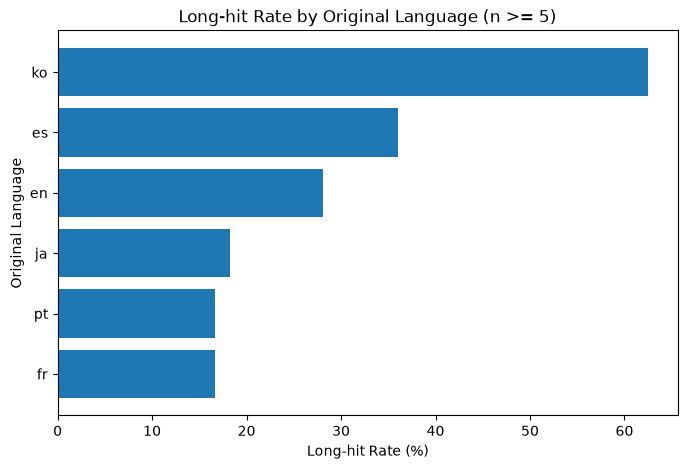

In [95]:
# 표본 5개 이상 언어의 장기흥행 비율을 막대그래프로 시각화

plot_data = language_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Original Language")
plt.title("Long-hit Rate by Original Language (n >= 5)")

plt.show()

### 원어별 장기흥행 비율

표본 수가 5개 이상인 언어를 기준으로 비교한 결과,
한국어(ko) 콘텐츠의 장기흥행 비율이 가장 높게 나타났다.

스페인어(es), 영어(en)가 그 뒤를 이었으며,
일본어(ja), 포르투갈어(pt), 프랑스어(fr)는 상대적으로 낮은 비율을 보였다.

다만 한국어 콘텐츠의 표본 수는 8개로 적기 때문에,
해당 결과를 일반화하기보다는 탐색적 경향으로 해석한다.

또한 언어 자체보다는 장르, 제작국가, 초기 확산 범위 등
다른 요인과 함께 장기흥행 여부를 확인할 필요가 있다.

In [96]:
# 제작국가 문자열을 개별 국가로 분리한 뒤 한 국가씩 행으로 펼치기

country_genre_df = merged_df.copy()

country_genre_df["production_country"] = (
    country_genre_df["production_countries"]
    .str.split(", ")
)

country_genre_df = country_genre_df.explode("production_country")

country_genre_df[
    ["show_title", "production_countries", "production_country", "long_hit"]
].head(10)

,show_title,production_countries,production_country,long_hit
0,A Tale Dark & Grimm,"CA, US",CA,0
0,A Tale Dark & Grimm,"CA, US",US,0
1,AlRawabi School for Girls,JO,JO,0
2,Alice in Borderland,JP,JP,1
3,All American,US,US,1
4,Another Life,CA,CA,0
5,Aranyak,IN,IN,0
6,Arcane,"FR, US",FR,1
6,Arcane,"FR, US",US,1
7,Atypical,US,US,0


In [97]:
# 제작국가별 콘텐츠 수와 장기흥행 비율을 계산

country_long_hit = (
    country_genre_df
    .dropna(subset=["production_country"])
    .groupby("production_country")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

country_long_hit

,content_count,long_hit_count,long_hit_rate
production_country,,,
AU,1,1,1.000000
CO,4,4,1.000000
DK,1,1,1.000000
IL,1,1,1.000000
KR,8,5,0.625000
FR,5,2,0.400000
US,78,26,0.333333
ES,14,4,0.285714
BR,5,1,0.200000


In [98]:
# 콘텐츠가 5개 이상인 제작국가만 남겨 장기흥행 비율을 비교

country_long_hit_filtered = country_long_hit[
    country_long_hit["content_count"] >= 5
].copy()

country_long_hit_filtered["long_hit_rate_pct"] = (
    country_long_hit_filtered["long_hit_rate"] * 100
).round(1)

country_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
production_country,,,,
KR,8,5,0.625000,62.5
FR,5,2,0.400000,40.0
US,78,26,0.333333,33.3
ES,14,4,0.285714,28.6
BR,5,1,0.200000,20.0
JP,11,2,0.181818,18.2
GB,6,1,0.166667,16.7
MX,8,1,0.125000,12.5
CA,5,0,0.000000,0.0


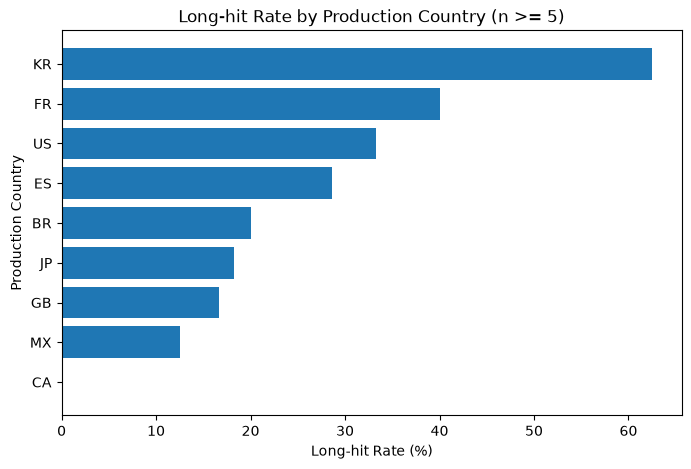

In [99]:
# 표본 5개 이상 제작국가의 장기흥행 비율을 막대그래프로 시각화

plot_data = country_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Production Country")
plt.title("Long-hit Rate by Production Country (n >= 5)")

plt.show()

### 제작국가별 장기흥행 비율

표본 수가 5개 이상인 제작국가를 기준으로 비교한 결과,
한국(KR) 제작 콘텐츠의 장기흥행 비율이 가장 높게 나타났다.

프랑스(FR), 미국(US), 스페인(ES)이 그 뒤를 이었으며,
일본(JP), 영국(GB), 멕시코(MX)는 상대적으로 낮은 비율을 보였다.

다만 일부 콘텐츠는 복수의 제작국가를 가지므로 하나의 작품이 여러 국가에 중복 포함될 수 있다.
또한 한국 제작 콘텐츠의 표본 수는 8개로 적기 때문에,
제작국가 자체의 효과로 일반화하기보다 탐색적 경향으로 해석한다.

In [100]:
# 장기흥행 여부에 따라 TMDB 평점과 투표 수의 평균·중앙값을 비교

vote_summary = (
    merged_df.groupby("long_hit")
    [["vote_average", "vote_count"]]
    .agg(["mean", "median"])
)

vote_summary

vote_average           vote_count        
                 mean  median         mean  median
long_hit                                          
0            7.396252  7.5320  2293.417391   415.0
1            7.811068  7.9465  3335.931818  1091.5

<Figure size 600x400 with 0 Axes>

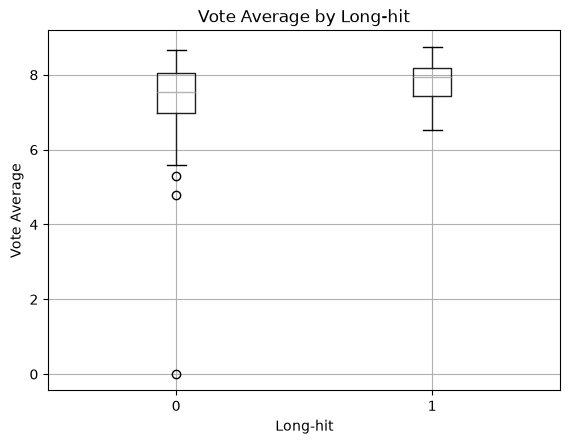

In [101]:
# 장기흥행 여부별 vote_average 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="vote_average",
    by="long_hit"
)

plt.title("Vote Average by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Vote Average")

plt.show()

### TMDB 평점 및 투표 수와 장기흥행

장기흥행 콘텐츠는 비장기흥행 콘텐츠보다
TMDB 평균 평점과 중앙값이 모두 다소 높게 나타났다.

또한 vote_count 역시 장기흥행 그룹에서 더 높았으며,
특히 중앙값 기준 차이가 크게 나타났다.

이는 장기흥행 콘텐츠가 더 높은 평가와 더 많은 사용자 반응을
확보한 경향이 있음을 보여준다.

다만 vote_count는 콘텐츠의 흥행 결과에 따라 증가할 수 있으므로,
장기흥행의 원인 변수라기보다 사후적 인기 지표일 가능성도 고려해야 한다.

<Figure size 600x400 with 0 Axes>

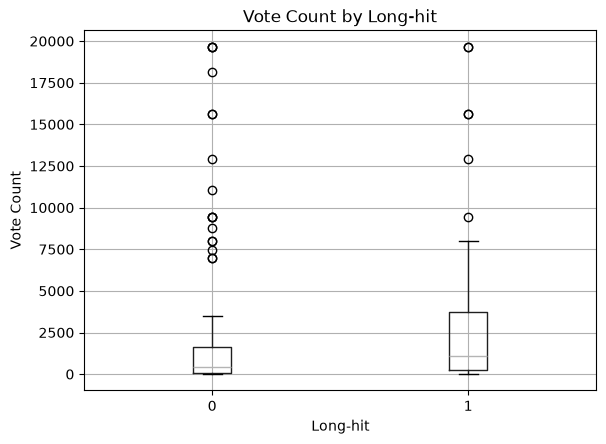

In [102]:
# 장기흥행 여부별 vote_count 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="vote_count",
    by="long_hit"
)

plt.title("Vote Count by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Vote Count")

plt.show()

<Figure size 600x400 with 0 Axes>

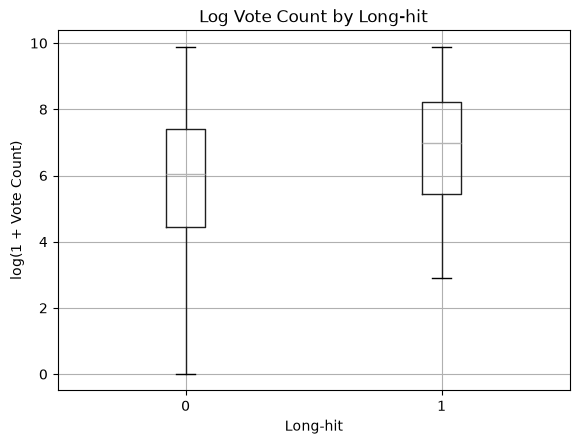

In [103]:
# vote_count의 큰 값 차이를 완화하기 위해 log1p 변환 후 장기흥행 여부별 분포를 비교

merged_df["log_vote_count"] = np.log1p(
    merged_df["vote_count"]
)

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="log_vote_count",
    by="long_hit"
)

plt.title("Log Vote Count by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("log(1 + Vote Count)")

plt.show()

### vote_count 로그 변환 비교

vote_count는 일부 작품의 투표 수가 매우 커서 분포가 오른쪽으로 치우쳐 있었다.
따라서 `log1p(vote_count)`로 로그 변환한 뒤 장기흥행 여부별 분포를 비교했다.

로그 변환 후에도 장기흥행 그룹(`long_hit=1`)의 중앙값이
비장기흥행 그룹보다 높게 나타났다.

이는 장기흥행 콘텐츠가 상대적으로 더 많은 사용자 평가를 받은 경향이 있음을 보여준다.

다만 vote_count는 콘텐츠가 오래 흥행한 결과로 증가했을 가능성도 있으므로,
장기흥행의 원인이라기보다 사후적 인기·관심 지표일 가능성을 함께 고려해야 한다.

In [104]:
# 장기흥행 여부에 따라 시즌 수와 에피소드 수의 평균·중앙값을 비교

season_episode_summary = (
    merged_df.groupby("long_hit")
    [["number_of_seasons", "number_of_episodes"]]
    .agg(["mean", "median"])
)

season_episode_summary

number_of_seasons        number_of_episodes       
                      mean median               mean median
long_hit                                                   
0                 4.061404    3.0          68.017544   27.5
1                 3.363636    3.0          63.090909   38.5

<Figure size 600x400 with 0 Axes>

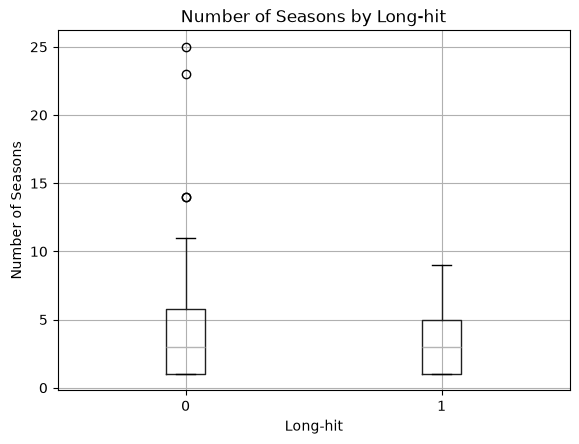

In [105]:
# 장기흥행 여부별 시즌 수 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="number_of_seasons",
    by="long_hit"
)

plt.title("Number of Seasons by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Number of Seasons")

plt.show()

<Figure size 600x400 with 0 Axes>

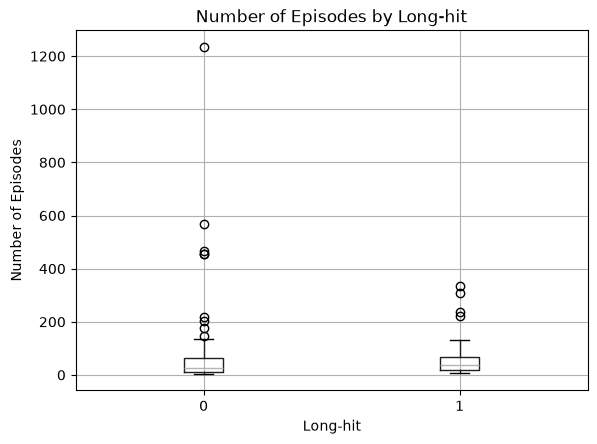

In [106]:
# 장기흥행 여부별 에피소드 수 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="number_of_episodes",
    by="long_hit"
)

plt.title("Number of Episodes by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Number of Episodes")

plt.show()

### 시즌 수와 에피소드 수

장기흥행 여부에 따라 시즌 수를 비교한 결과,
두 그룹의 중앙값은 모두 3으로 동일했다.

비장기흥행 그룹에서 시즌 수가 매우 많은 일부 장수 시리즈가 존재해
평균 시즌 수는 오히려 비장기흥행 그룹에서 더 높게 나타났다.

에피소드 수 역시 일부 장수 프로그램의 영향으로
비장기흥행 그룹의 평균값이 더 높았지만,
중앙값은 장기흥행 그룹이 38.5편으로
비장기흥행 그룹의 27.5편보다 높게 나타났다.

따라서 시즌 수나 전체 에피소드 수가 많다는 사실만으로
장기흥행 여부를 설명하기는 어려우며,
특히 극단적으로 많은 에피소드 수를 가진 작품의 영향을 고려할 필요가 있다.